In [2]:
# Shastry-Sutherland model in two dimension
# Parameters: J1, J2=1
# Monopole operator defined in PHYSICAL REVIEW X 9, 041037 (2019)

import netket as nk
import numpy as np
import math
import matplotlib.pyplot as plt
import json

# dimer coupling, set as 1
# J2=1
# horizontal and vertical bond, J1/J2 will be varied
# J1=0.71

# number of unit cells L*L
L = 3

# set up the square lattice, notice the sequence of the basis vectors
g=nk.graph.Lattice(basis_vectors=[[0,1],[1,0]],extent=[L,L],
                   pbc=[True,True],atoms_coord=[[0,0],[0.5,0],[0,0.5],[0.5,0.5]]) 

# Hilbert space for spin 1/2, confined to S_z=0
hi = nk.hilbert.Spin(graph=g, s=0.5, total_sz=0)

# Pauli Matrices
sigmaz = np.array([[1, 0], [0, -1]])
sigmax = np.array([[0, 1], [1, 0]])
sigmay = np.array([[0, -1j], [1j, 0]])

# manually set up Heisenberg exchange, spin 1/2
ss = np.kron(sigmax,sigmax) + np.kron(sigmay,sigmay) + np.kron(sigmaz,sigmaz)

# number of sites
Ns=g.n_sites
assert Ns % 4 == 0

# number of unit cells
Nu = int(Ns/4)
# shifting needed from A -> B ->C -> D site, bookkeeping
bshift = Nu
cshift = 2*Nu
dshift = 3*Nu

# function to set /reset the Hamiltonian
def hamilton(j1, j2):

    h1 = (0.25*j1*ss).tolist()
    h2 = (0.25*j2*ss).tolist()
    
    # empty lists to store the sites (pair) and the corresponding operators (exchange interaction)
    sites = []
    operators = []
    # not used in calculation, only for debugging
    bondcolor =[]

    # loop over all the regular edges, h1
    for eg in g.edges: 
        sites.append(list(eg))
        operators.append(h1)
        bondcolor.append('b')
    
    # loop over the unit cells, set h2
    for i in range(Nu):    
        a_site = i
        # lattice coordinates of site a, (y,x), note the sequene
        [m,n] = g.site_to_vector(i) 

        # site d within the same unit cell
        d_site = a_site + dshift     
        # diagonal ad bond
        sites.append([a_site,d_site])
        operators.append(h2)
        bondcolor.append('r')

        # site c, within the same unit cell
        c_site = a_site + cshift 

        # site b, not the same unit cell, shift to left and up
        b_site = g.vector_to_site([(m+1)%L,(n-1)%L]) + bshift

        # diagonal cb bond
        sites.append([c_site,b_site])
        operators.append(h2)
        bondcolor.append('g')

        '''
        # check open boundary condition
        if (n-1) >= 0 and (m+1)< L:
            b_site = g.vector_to_site([(m+1),(n-1)]) + bshift
            sites.append([c_site,b_site])
            operators.append(h2)
        '''

    # set up the Hamiltonian using the sites and operators
    ham = nk.operator.LocalOperator(hi, operators=operators, acting_on=sites)
    return ham

# Define the machine, RBM, no symmetry
# ma = nk.machine.RbmSpin(hilbert=hi, alpha=2)
# ma.init_random_parameters(seed=1234, sigma=0.01)

# FFNN
alpha = 2
layers = (nk.layer.FullyConnected(input_size=Ns,output_size=int(alpha*Ns),use_bias=True),
          nk.layer.Lncosh(input_size=int(alpha*Ns)),
          #nk.layer.FullyConnected(input_size=int(alpha*Ns),output_size=int(alpha*Ns),use_bias=True),
          #nk.layer.Lncosh(input_size=int(alpha*Ns)),
          nk.layer.SumOutput(input_size=int(alpha*Ns))
         )
for layer in layers:
    layer.init_random_parameters(sigma=0.01)

# machine, only care about layers and the hilbert space
ma = nk.machine.FFNN(hi, layers)

# specify sampler
sa = nk.sampler.MetropolisExchange(ma)

# Optimizer
op=nk.optimizer.Sgd(learning_rate=0.015,decay_factor=1)

j1 = 0.6
ha = hamilton(j1, 1.0)

# VMC via Stochastic Reconfiguration to ground state
gs = nk.variational.Vmc(
    hamiltonian=ha,
    sampler=sa,
    optimizer=op,
    n_samples=1000,
    diag_shift=0.1,
    use_iterative=True,
    method='Sr')

In [ ]:
# run simulations, less than 2 seconds per iteration
gs.run(out=('FF'+str(j1)[:4]), n_iter=2500)

In [20]:
for j1 in np.linspace(0.5, 0.9, 41):
    print('FF'+str(j1)[:4])

FF0.5
FF0.51
FF0.52
FF0.53
FF0.54
FF0.55
FF0.56
FF0.57
FF0.58
FF0.59
FF0.6
FF0.61
FF0.62
FF0.63
FF0.64
FF0.65
FF0.66
FF0.67
FF0.67
FF0.69
FF0.7
FF0.71
FF0.72
FF0.73
FF0.74
FF0.75
FF0.76
FF0.77
FF0.78
FF0.79
FF0.8
FF0.81
FF0.82
FF0.83
FF0.84
FF0.85
FF0.86
FF0.87
FF0.88
FF0.89
FF0.9


In [15]:
# After sufficient iterations, we compute the observables --- it takes time

import netket as nk
import numpy as np
import math
import matplotlib.pyplot as plt
import json

# number of unit cells L*L
L = 3

# set up the square lattice, notice the sequence of the basis vectors
g=nk.graph.Lattice(basis_vectors=[[0,1],[1,0]],extent=[L,L],
                   pbc=[True,True],atoms_coord=[[0,0],[0.5,0],[0,0.5],[0.5,0.5]]) 

# Hilbert space for spin 1/2, confined to S_z=0
hi = nk.hilbert.Spin(graph=g, s=0.5, total_sz=0)

# Pauli Matrices
sigmaz = np.array([[1, 0], [0, -1]])
sigmax = np.array([[0, 1], [1, 0]])
sigmay = np.array([[0, -1j], [1j, 0]])

# manually set up Heisenberg exchange, spin 1/2
ss = np.kron(sigmax,sigmax) + np.kron(sigmay,sigmay) + np.kron(sigmaz,sigmaz)

# number of sites
Ns=g.n_sites
assert Ns % 4 == 0

# number of unit cells
Nu = int(Ns/4)
# shifting needed from A -> B ->C -> D site, bookkeeping
bshift = Nu
cshift = 2*Nu
dshift = 3*Nu

# function to set /reset the Hamiltonian
def hamilton(j1, j2):

    h1 = (0.25*j1*ss).tolist()
    h2 = (0.25*j2*ss).tolist()
    
    # empty lists to store the sites (pair) and the corresponding operators (exchange interaction)
    sites = []
    operators = []
    # not used in calculation, only for debugging
    bondcolor =[]

    # loop over all the regular edges, h1
    for eg in g.edges: 
        sites.append(list(eg))
        operators.append(h1)
        bondcolor.append('b')
    
    # loop over the unit cells, set h2
    for i in range(Nu):    
        a_site = i
        # lattice coordinates of site a, (y,x), note the sequene
        [m,n] = g.site_to_vector(i) 

        # site d within the same unit cell
        d_site = a_site + dshift     
        # diagonal ad bond
        sites.append([a_site,d_site])
        operators.append(h2)
        bondcolor.append('r')

        # site c, within the same unit cell
        c_site = a_site + cshift 

        # site b, not the same unit cell, shift to left and up
        b_site = g.vector_to_site([(m+1)%L,(n-1)%L]) + bshift

        # diagonal cb bond
        sites.append([c_site,b_site])
        operators.append(h2)
        bondcolor.append('g')

    # set up the Hamiltonian using the sites and operators
    ham = nk.operator.LocalOperator(hi, operators=operators, acting_on=sites)
    return ham

# Define the machine, RBM, no symmetry
# ma = nk.machine.RbmSpin(hilbert=hi, alpha=2)
# ma.init_random_parameters(seed=1234, sigma=0.01)

# FFNN
alpha = 2
layers = (nk.layer.FullyConnected(input_size=Ns,output_size=int(alpha*Ns),use_bias=True),
          nk.layer.Lncosh(input_size=int(alpha*Ns)),
          #nk.layer.FullyConnected(input_size=int(alpha*Ns),output_size=int(alpha*Ns),use_bias=True),
          #nk.layer.Lncosh(input_size=int(alpha*Ns)),
          nk.layer.SumOutput(input_size=int(alpha*Ns))
         )
for layer in layers:
    # this is useless here because the machine will be loaded from the file
    layer.init_random_parameters(sigma=0.01)

# machine, only care about layers and the hilbert space
ma = nk.machine.FFNN(hi, layers)

# specify sampler
sa = nk.sampler.MetropolisExchange(ma)

# Optimizer
op=nk.optimizer.Sgd(learning_rate=0.015,decay_factor=1)

# construct observables, as a sum, similar to the hamiltonian
ops = []
sites = []
for i in range(Nu):
    a_site = i
    ops.append(sigmax.tolist())
    sites.append([a_site])
    
    d_site = a_site + dshift 
    ops.append(sigmax.tolist())
    sites.append([d_site])
    
    b_site = a_site + bshift 
    ops.append((-sigmax).tolist())
    sites.append([b_site])

    c_site = a_site + cshift 
    ops.append((-sigmax).tolist())
    sites.append([c_site])
# sublattice magnetization, Neel order, x component    
sx = nk.operator.LocalOperator(hi, ops, sites)

ops = []
# sites remain the same
for i in range(Nu):
    ops.append(sigmay.tolist())
    ops.append(sigmay.tolist())
    ops.append((-sigmay).tolist())
    ops.append((-sigmay).tolist())
sy = nk.operator.LocalOperator(hi, ops, sites)

ops = []
for i in range(Nu):
    ops.append(sigmaz.tolist())
    ops.append(sigmaz.tolist())
    ops.append((-sigmaz).tolist())
    ops.append((-sigmaz).tolist())
sz = nk.operator.LocalOperator(hi, ops, sites)

# monopole operator, vx and vy
iden = np.array([[1, 0], [0, 1]])
singlet  = ( 0.25*np.kron(iden, iden) - ss).tolist()
msinglet = (-0.25*np.kron(iden, iden) + ss).tolist()
ops = []
sites = []
for i in range(Nu):
    a_site = i
    b_site = a_site + bshift
    ops.append(singlet)
    sites.append([a_site, b_site])
    
    [m,n] = g.site_to_vector(i) 
    # a_prime site move to right by one step
    a_prime = g.vector_to_site([m,(n+1)%L])
    ops.append(msinglet)
    sites.append([b_site, a_prime])
    
    c_site = a_site + cshift 
    d_site = a_site + dshift 
    ops.append(singlet)
    sites.append([c_site, d_site])
    
    c_prime = a_prime + cshift 
    ops.append(msinglet)
    sites.append([d_site, c_prime])    
vx = nk.operator.LocalOperator(hi, ops, sites)

ops = []
sites = []
for i in range(Nu):
    a_site = i
    c_site = a_site + cshift
    ops.append(singlet)
    sites.append([a_site, c_site])
    
    [m,n] = g.site_to_vector(i) 
    # a_prime site move up by one step
    a_prime = g.vector_to_site([(m+1)%L, n])
    ops.append(msinglet)
    sites.append([c_site, a_prime])
    
    b_site = a_site + bshift 
    d_site = a_site + dshift 
    ops.append(singlet)
    sites.append([b_site, d_site])
    
    b_prime = a_prime + bshift 
    ops.append(msinglet)
    sites.append([d_site, b_prime])    
vy = nk.operator.LocalOperator(hi, ops, sites)

observables = {"Vx": vx, "Vy": vy, "Sx": sx, "Sy": sy, "Sz": sz}

for j1 in np.linspace(0.5, 0.9, 41):
    # load the wavefunction data stored to the machine,
    fname = 'FF' + str(j1)[:4] + '.wf'
    ma.load(fname)
    
    # we increase the n_samples to 2K
    gs = nk.variational.Vmc(
    hamiltonian=hamilton(j1, 1.0),
    sampler=sa,
    optimizer=op,
    n_samples=2000,
    diag_shift=0.1,
    use_iterative=True,
    method='Sr')
    
    # run one step to compute the observables and save
    gs.run(n_iter=1, out=('OBS'+str(j1)[:4]), obs=observables)


In [5]:
# load data, continue the run
J1=0.71
ma.load('FF-0.71.wf')

gs.n_samples=2000
gs.run(n_iter=100, out="test", obs=obs)

#result = gs.estimate(obs)
# old way:
#gs.add_observable(structure_factor, "Structure Factor")
#gs.run(out="test", n_iter=1)
#print(result)
#print(result["Vx"].mean)
#print(result["Vx"].error_of_mean)

100%|██████████| 100/100 [10:07<00:00,  6.08s/it, Energy=(-11.929 + 0.006i) ± 0.029 [var=1.156, R=1.00199]]


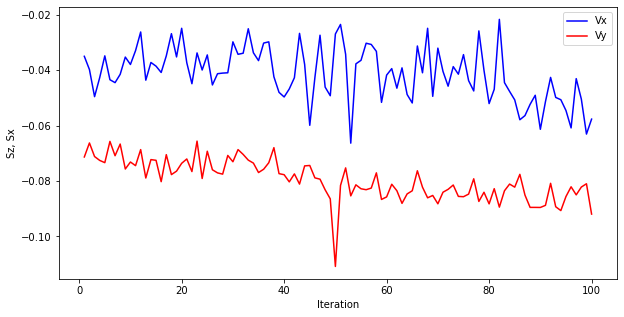

In [7]:
data=json.load(open("test.log"))

st = []
vx = []
vy = []

for iteration in data["Output"]:
    vx.append(iteration["Sz"]["Mean"]*(1.0/Ns))
    vy.append(iteration["Sx"]["Mean"]*(1.0/Ns))
    st.append(iteration["Iteration"])
      
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(st, vx, color='b', label='Vx')
ax1.plot(st, vy, color='r', label='Vy')
ax1.set_ylabel('Sz, Sx')
ax1.set_xlabel('Iteration')

ax1.legend()
plt.show()

In [8]:
# adjust parameter
#J1 = 0.69
#gs.hamiltonian = hamilton(J1,J2)

# adjust optimizer learning rate
#gs.optimizer=nk.optimizer.Sgd(learning_rate=0.02,decay_factor=1)

# adjust MC n_samples
#gs.n_samples=2000

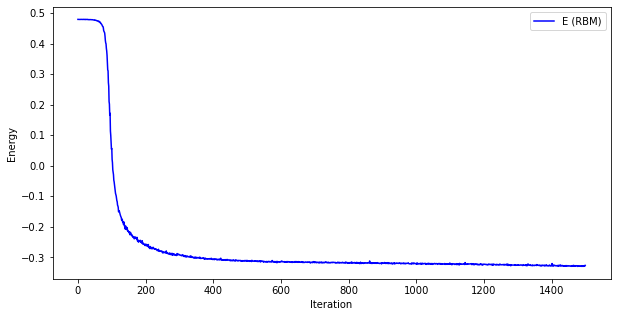

E (per site) =  -0.32644030601604307


In [3]:
data=json.load(open("FF-0.71.log"))

en = []
de = []
st = []

for iteration in data["Output"]:
    en.append(iteration["Energy"]["Mean"]*(1.0/Ns))
    de.append(iteration["Energy"]["Sigma"]*(1.0/Ns))
    st.append(iteration["Iteration"])
      
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(st, en, color='b', label='E (RBM)')
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')

ax1.legend()
plt.show()

#print("The energy per site is −0.75 per dimer, -0.375 per site in the dimer limit ")
print("E (per site) = ", en[-1])

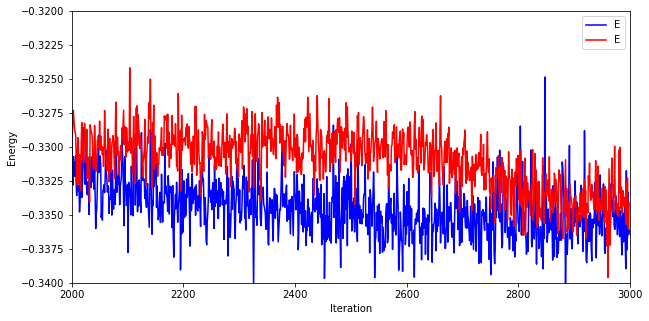

E (per site) =  -0.3341200586275974


In [7]:
import netket as nk
import numpy as np
import math
import matplotlib.pyplot as plt
import json

# plot the energy, alpha = 2
data=json.load(open("FF0.5.log"))

en = []
de = []
st = []
Ns=64

for iteration in data["Output"]:
    en.append(iteration["Energy"]["Mean"]*(1.0/Ns))
    de.append(iteration["Energy"]["Sigma"]*(1.0/Ns))
    st.append(iteration["Iteration"])
      
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(st, en, color='b', label='E')
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')

data=json.load(open("ADA0.5.log"))

en = []
de = []
st = []
Ns=64

for iteration in data["Output"]:
    en.append(iteration["Energy"]["Mean"]*(1.0/Ns))
    de.append(iteration["Energy"]["Sigma"]*(1.0/Ns))
    st.append(iteration["Iteration"])

ax1.plot(st, en, color='r', label='E')
ax1.set_ylim([-0.34, -0.32])
ax1.set_xlim([2000,3000])
ax1.legend()
plt.show()

#print("The energy per site is −0.75 per dimer, -0.375 per site in the dimer limit ")
print("E (per site) = ", en[-1])

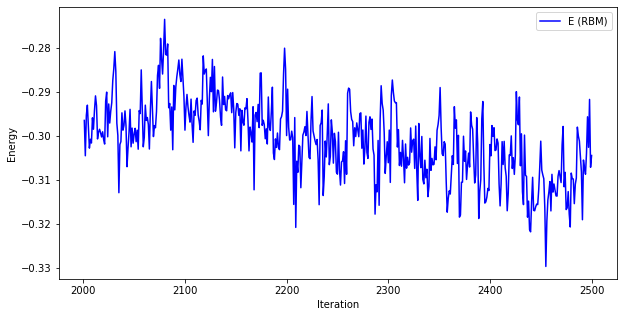

E (per site) =  -0.3044527669067426


In [41]:
# plot the energy, alpha = 2
data=json.load(open("SS2.log"))

en = []
de = []
st = []

for iteration in data["Output"]:
    en.append(iteration["Energy"]["Mean"]*(1.0/Ns))
    de.append(iteration["Energy"]["Sigma"]*(1.0/Ns))
    st.append(iteration["Iteration"])
      
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(st, en, color='b', label='E (RBM)')
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')

ax1.legend()
plt.show()

#print("The energy per site is −0.75 per dimer, -0.375 per site in the dimer limit ")
print("E (per site) = ", en[-1])

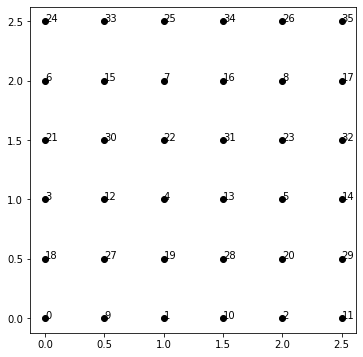

In [21]:
# check the lattice
# plot the sites 

x = [g.site_to_coord(i)[0] for i in range(g.n_sites)]
y = [g.site_to_coord(i)[1] for i in range(g.n_sites)]

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
ax.set_aspect('equal')
plt.plot(x, y, 'o', color='black')

for i in range(g.n_sites): 
    [xi,yi] = g.site_to_coord(i)
    ax.text(xi, yi, str(i))
plt.show()    

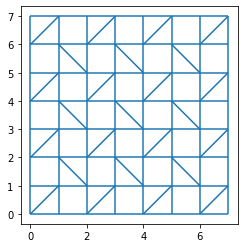

In [17]:
# check the open boundary
from matplotlib.collections import LineCollection 

lines = []
for eg in sites:
    (x1,y1) = g.site_to_coord(eg[0])
    (x2,y2) = g.site_to_coord(eg[1])
    lines.append([(x1,y1),(x2,y2)])
    
lc = LineCollection(lines)
fig, ax = plt.subplots()
ax.add_collection(lc)
ax.autoscale()
ax.set_aspect('equal')

plt.show()

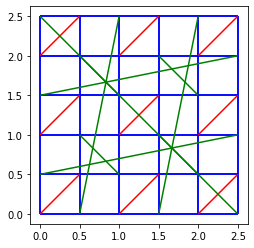

In [22]:
from matplotlib.collections import LineCollection 

lines = []
for eg in sites:
    (x1,y1) = g.site_to_coord(eg[0])
    (x2,y2) = g.site_to_coord(eg[1])
    lines.append([(x1,y1),(x2,y2)])
    
lc = LineCollection(lines,colors=bondcolor)
fig, ax = plt.subplots()
ax.add_collection(lc)
ax.autoscale()
ax.set_aspect('equal')

plt.show()

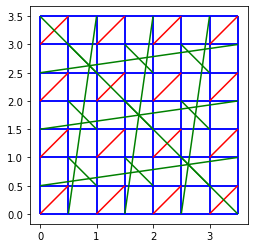

In [19]:
from matplotlib.collections import LineCollection 

lines = []
for eg in sites:
    (x1,y1) = g.site_to_coord(eg[0])
    (x2,y2) = g.site_to_coord(eg[1])
    lines.append([(x1,y1),(x2,y2)])
    
lc = LineCollection(lines,colors=bondcolor)
fig, ax = plt.subplots()
ax.add_collection(lc)
ax.autoscale()
ax.set_aspect('equal')

plt.show()

In [ ]:
# Convnet machine with 7 layers (of which 3 are convolutions)
layers = (
    nk.layer.ConvolutionalHypercube(
        length=L,
        n_dim=1,
        input_channels=1,
        output_channels=2,
        stride=1,
        kernel_length=10,
        use_bias=True,
    ),
    nk.layer.Relu(input_size=2 * L),
    nk.layer.ConvolutionalHypercube(
        length=L,
        n_dim=1,
        input_channels=2,
        output_channels=2,
        stride=1,
        kernel_length=5,
        use_bias=True,
    ),
    nk.layer.Relu(input_size=(2 * L)),
    nk.layer.ConvolutionalHypercube(
        length=L,
        n_dim=1,
        input_channels=2,
        output_channels=1,
        stride=1,
        kernel_length=3,
        use_bias=True,
    ),
    nk.layer.Relu(input_size=(L)),
    nk.layer.SumOutput(input_size=(L)),
)
for layer in layers:
    layer.init_random_parameters(seed=12345, sigma=0.01)

ffnn = nk.machine.FFNN(hi, layers)